## NYC Taxi Trip Duration Prediction

**Problem Statement:**

Ride-hailing services are services that use online-enabled platforms to connect passengers and local drivers using their personal vehicles. In most cases, they are a comfortable method for door-to-door transport. Usually, they are cheaper than using licensed taxicabs. Examples of ride-hailing services include Uber and Lyft.

To improve the efficiency of taxi dispatching systems for such services, it is important to be able to predict how long a driver will have his taxi occupied. If a dispatcher knew approximately when a taxi driver would be ending their current ride, they would be better able to identify which driver to assign to each pickup request. So, we can try to predict the trip duration using machine learning regression models.

**Data Dictionary:**

id - a unique identifier for each trip

vendor_id - a code indicator of the provider associated with the trip record

pickup_datetime - date and time when the meter was engaged

dropoff_datetime - date and time when the meter was disengaged

passenger_count - the number of passengers in the vehicle (driver entered value)

pickup_longitude - the longitude where the meter was engaged

pickup_latitude - the latitude where the meter was engaged

dropoff_longitude - the longitude where the meter was disengaged

dropoff_latitude - the latitude where the meter was disengaged

store_and_fwd_flag - This flag indicates whether the trip record was held in

vehicle memory before sending to the vendor because the vehicle did not have a connection to the server (Y = store and forward; N = not a store and forward trip)

trip_duration - (target) duration of the trip in seconds

## Objective

The objective of this project is to predict the duration of NYC taxi trips using machine learning techniques.

This project includes:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Building
- Model Evaluation

## Data Cleaning

In this step:
- Missing values were checked
- Incorrect values were handled
- Outliers were removed
- Datetime columns were converted

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_nyc = pd.read_csv(r"C:\Users\harsh kasana\Downloads\nyc_taxi_trip_duration.csv")

In [3]:
df_nyc.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,29-02-2016 16:40,29-02-2016 16:47,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,11-03-2016 23:35,11-03-2016 23:53,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,21-02-2016 17:59,21-02-2016 18:26,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,05-01-2016 09:44,05-01-2016 10:03,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,17-02-2016 06:42,17-02-2016 06:56,1,-74.017120,40.708469,-73.988182,40.740631,N,848


In [4]:
df_nyc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  729322 non-null  object 
 1   vendor_id           729322 non-null  int64  
 2   pickup_datetime     729322 non-null  object 
 3   dropoff_datetime    729322 non-null  object 
 4   passenger_count     729322 non-null  int64  
 5   pickup_longitude    729322 non-null  float64
 6   pickup_latitude     729322 non-null  float64
 7   dropoff_longitude   729322 non-null  float64
 8   dropoff_latitude    729322 non-null  float64
 9   store_and_fwd_flag  729322 non-null  object 
 10  trip_duration       729322 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 61.2+ MB


In [5]:
df_nyc.shape

(729322, 11)

In [6]:
df_nyc.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,729322.000000,729322.000000,729322.000000,729322.000000,729322.000000,729322.000000,7.293220e+05
mean,1.535403,1.662055,-73.973513,40.750919,-73.973422,40.751775,9.522291e+02
std,0.498745,1.312446,0.069754,0.033594,0.069588,0.036037,3.864626e+03
min,1.000000,0.000000,-121.933342,34.712235,-121.933304,32.181141,1.000000e+00
25%,1.000000,1.000000,-73.991859,40.737335,-73.991318,40.735931,3.970000e+02
50%,2.000000,1.000000,-73.981758,40.754070,-73.979759,40.754509,6.630000e+02
75%,2.000000,2.000000,-73.967361,40.768314,-73.963036,40.769741,1.075000e+03
max,2.000000,9.000000,-65.897385,51.881084,-65.897385,43.921028,1.939736e+06


In [7]:
df_nyc.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [8]:
df_nyc.duplicated().sum()

np.int64(0)

**Univariate Analysis**

In [9]:
df_nyc['pickup_datetime'] = pd.to_datetime(df_nyc['pickup_datetime'], format='%d-%m-%Y %H:%M')
df_nyc['dropoff_datetime'] = pd.to_datetime(df_nyc['dropoff_datetime'], format='%d-%m-%Y %H:%M')
df_nyc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  729322 non-null  object        
 1   vendor_id           729322 non-null  int64         
 2   pickup_datetime     729322 non-null  datetime64[ns]
 3   dropoff_datetime    729322 non-null  datetime64[ns]
 4   passenger_count     729322 non-null  int64         
 5   pickup_longitude    729322 non-null  float64       
 6   pickup_latitude     729322 non-null  float64       
 7   dropoff_longitude   729322 non-null  float64       
 8   dropoff_latitude    729322 non-null  float64       
 9   store_and_fwd_flag  729322 non-null  object        
 10  trip_duration       729322 non-null  int64         
dtypes: datetime64[ns](2), float64(4), int64(3), object(2)
memory usage: 61.2+ MB


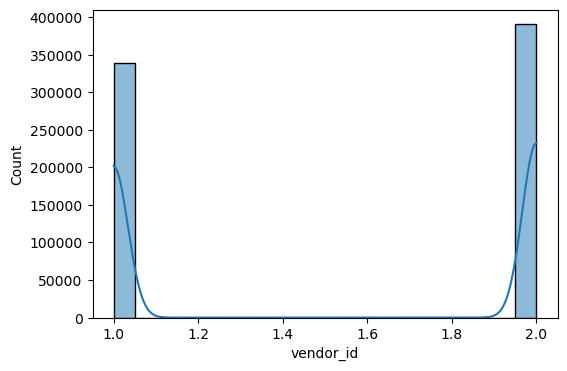

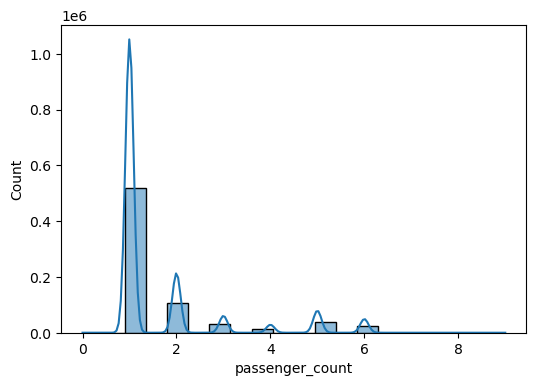

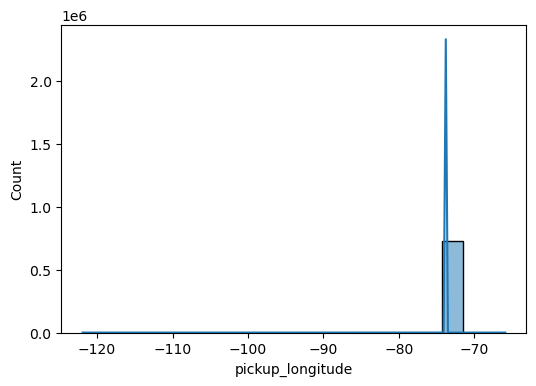

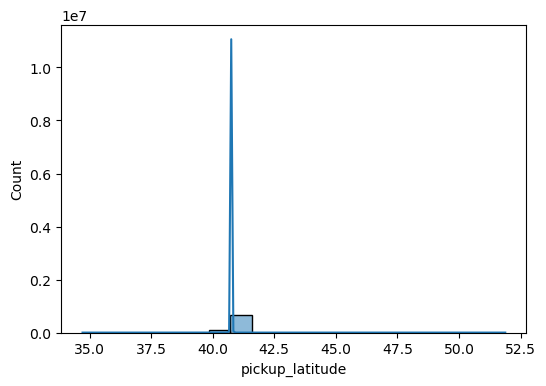

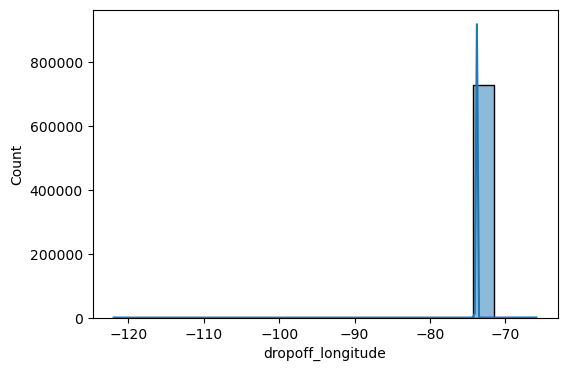

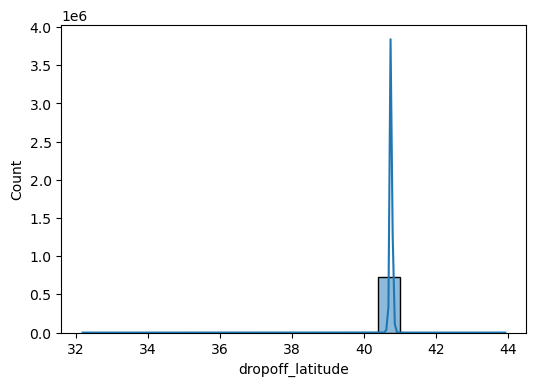

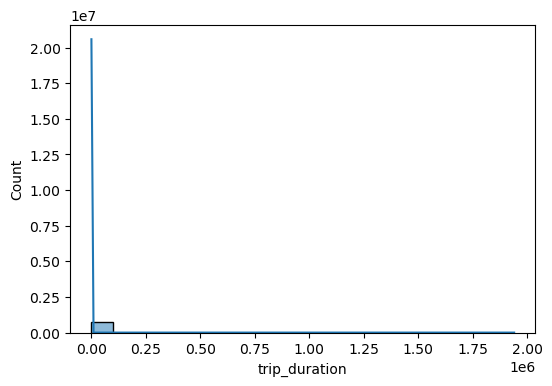

In [10]:
numeric_column=["vendor_id","passenger_count","pickup_longitude","pickup_latitude","dropoff_longitude","dropoff_latitude","trip_duration"]
for col in numeric_column:
    plt.figure(figsize=(6,4))
    sns.histplot(df_nyc[col],kde=True,bins=20)

Value counts for vendor_id:
vendor_id
2    390481
1    338841
Name: count, dtype: int64


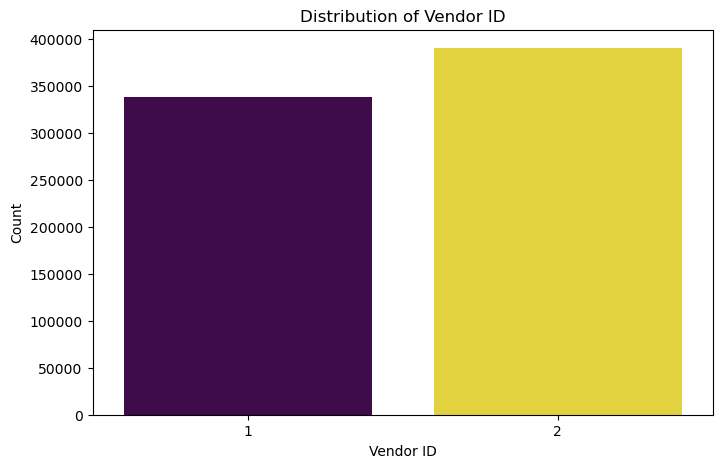

In [11]:
# Value counts for vendor_id
print('Value counts for vendor_id:')
print(df_nyc['vendor_id'].value_counts())

# Count plot for vendor_id
plt.figure(figsize=(8, 5))
sns.countplot(x='vendor_id', data=df_nyc, palette='viridis', hue='vendor_id', legend=False)
plt.title('Distribution of Vendor ID')
plt.xlabel('Vendor ID')
plt.ylabel('Count')
plt.show()

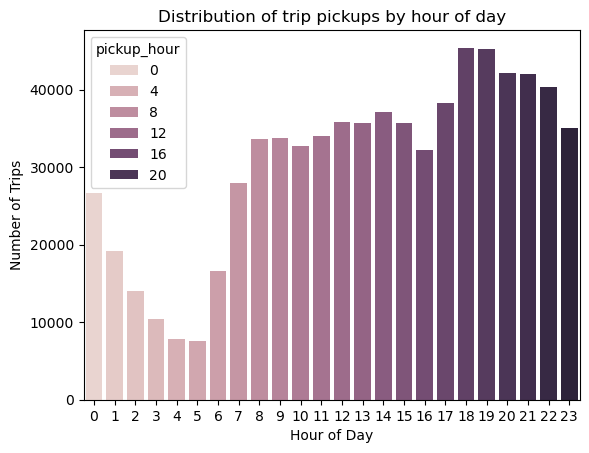

In [12]:
df_nyc['pickup_hour'] = df_nyc['pickup_datetime'].dt.hour
 
sns.countplot(x="pickup_hour",data = df_nyc,hue = "pickup_hour")
plt.title("Distribution of trip pickups by hour of day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

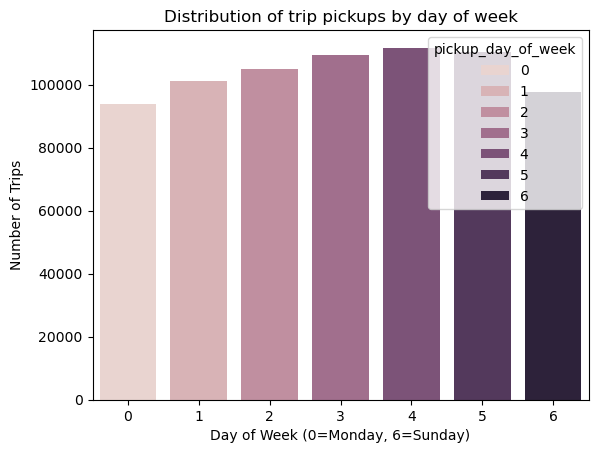

In [13]:
df_nyc['pickup_day_of_week'] = df_nyc['pickup_datetime'].dt.dayofweek 
sns.countplot(x="pickup_day_of_week",data = df_nyc,hue = "pickup_day_of_week")
plt.title("Distribution of trip pickups by day of week")
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel("Number of Trips")
plt.show()

#### **Observations for pickup_datetime (derived features: pickup_hour, pickup_day_of_week)**

*   **pickup_hour**: Trip pickups are most frequent during the afternoon and evening hours (peaking around 18:00 or 6 PM), and lowest during early morning hours (e.g., 4 AM to 6 AM). This reflects typical commuting and social activity patterns.
*   **pickup_day_of_week**: Trip activity is relatively consistent throughout weekdays, with a slight dip over the weekend (Saturday and Sunday). Friday appears to be the busiest day.

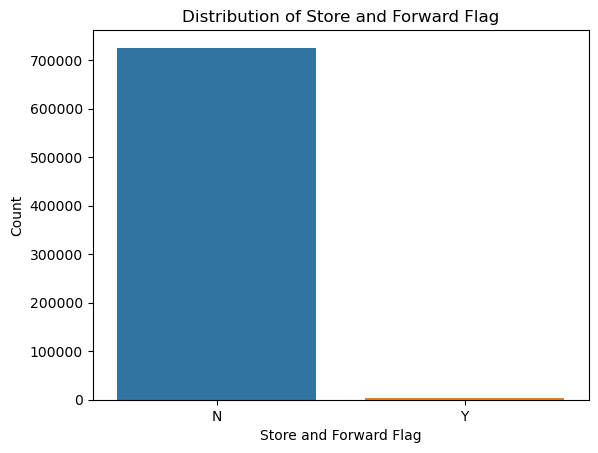

In [14]:
sns.countplot(x="store_and_fwd_flag",data = df_nyc,hue = "store_and_fwd_flag")
plt.title("Distribution of Store and Forward Flag")
plt.xlabel("Store and Forward Flag")
plt.ylabel("Count")
plt.show()

**Bivariate Analysis**

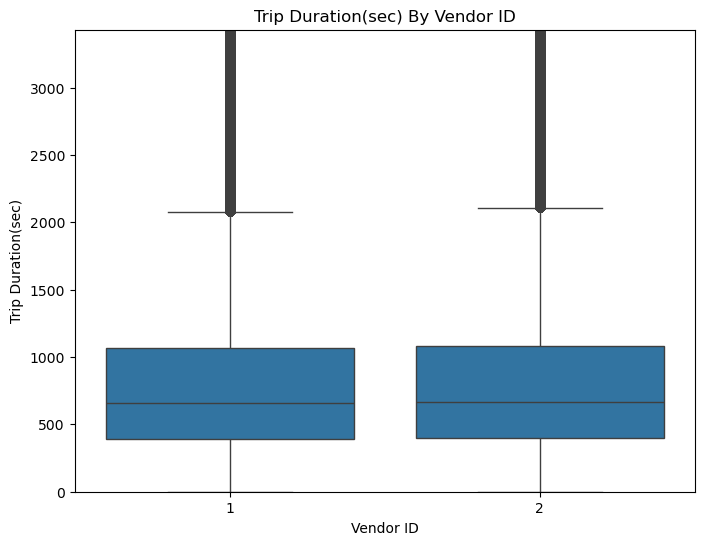

In [15]:
df_nyc["trip_duration_seconds"] = df_nyc["trip_duration"] * 3600
plt.figure(figsize=(8, 6))
sns.boxplot(x="vendor_id",y="trip_duration",data = df_nyc)
plt.title("Trip Duration(sec) By Vendor ID")
plt.xlabel("Vendor ID")
plt.ylabel("Trip Duration(sec)")
plt.ylim(0, df_nyc['trip_duration'].quantile(0.99))  # limiting y-axis for better visualization
plt.show()

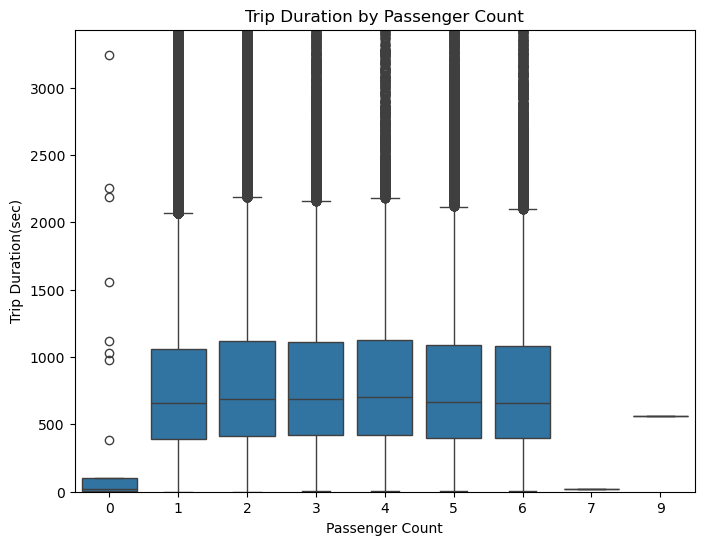

In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="passenger_count",y="trip_duration",data = df_nyc)
plt.title("Trip Duration by Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Trip Duration(sec)")
plt.ylim(0, df_nyc['trip_duration'].quantile(0.99))  # limiting y-axis for better visualization
plt.show()

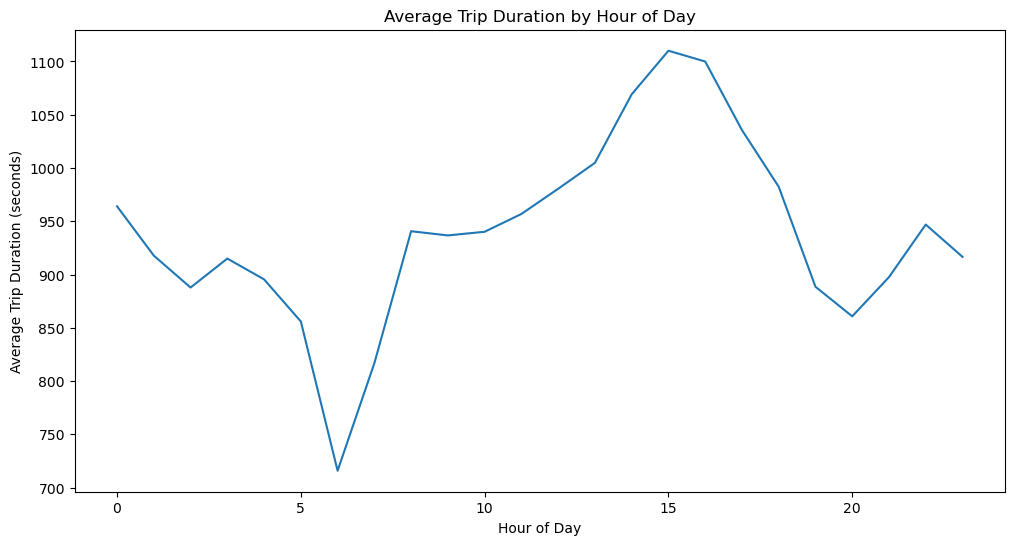

In [17]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='pickup_hour', y='trip_duration', data=df_nyc.groupby('pickup_hour')['trip_duration'].mean().reset_index())
plt.title('Average Trip Duration by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Trip Duration (seconds)')
plt.show()

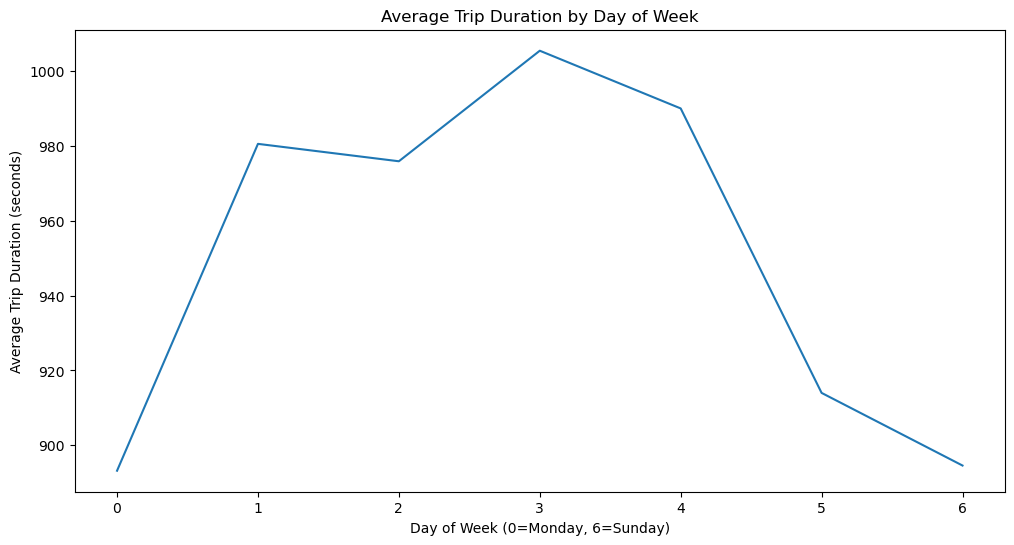

In [18]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='pickup_day_of_week', y='trip_duration', data=df_nyc.groupby('pickup_day_of_week')['trip_duration'].mean().reset_index())
plt.title('Average Trip Duration by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Trip Duration (seconds)')
plt.show()

cols = [
    "passenger_count",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "trip_duration"]

sns.pairplot(
    df_nyc[cols],
    y_vars=["trip_duration"],   # focus on duration
    height=2)
plt.show()

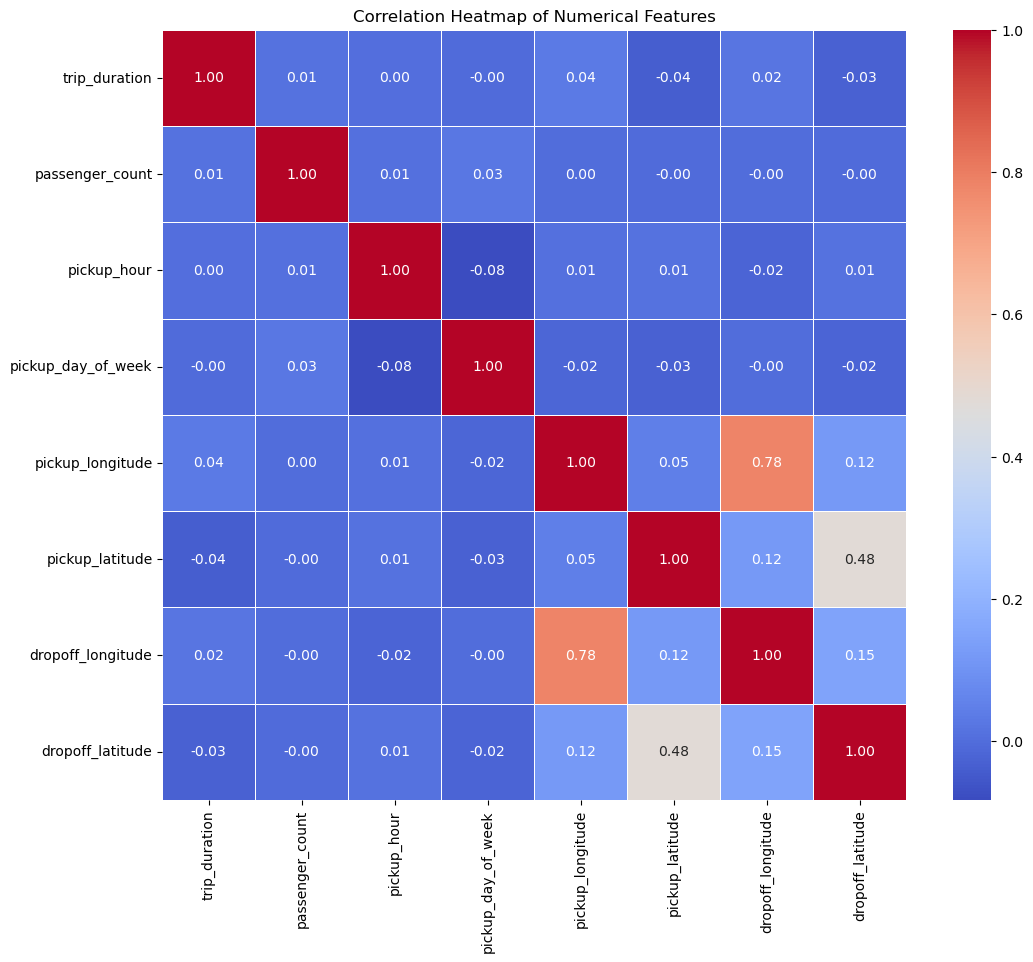

In [19]:
features_for_heatmap = ['trip_duration', 'passenger_count', 'pickup_hour', 'pickup_day_of_week',
                        'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']

df_heatmap = df_nyc[features_for_heatmap]

correlation_matrix = df_heatmap.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


## Outliers Analysis

=== Before Filtering ===
Shortest trip : 1 seconds
Longest trip  : 1939736 seconds
Cut-off (low) : 2.0 seconds
Cut-off (high): 86327.0 seconds

=== Rows Removed ===
Before : 729322 rows
After  : 729237 rows
Removed: 85 rows

=== Summary After Cleaning ===
count    729237.000000
mean        941.273085
std        3012.038366
min           2.000000
25%         397.000000
50%         663.000000
75%        1075.000000
max       86327.000000
Name: trip_duration, dtype: float64


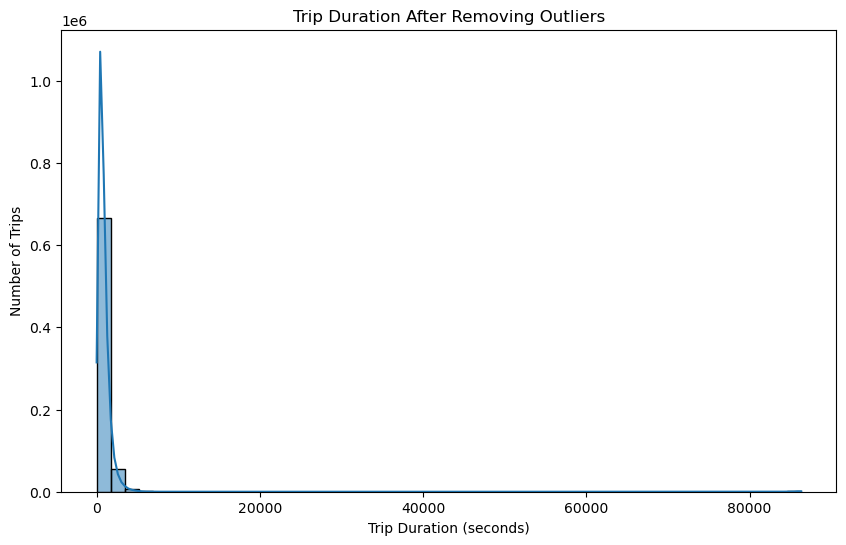

In [20]:
# Step 1: Find the acceptable range for trip duration
# We remove very short and very long trips (extreme outliers)
lower_bound = df_nyc['trip_duration'].quantile(0.0001)  # Bottom 0.01%
upper_bound = df_nyc['trip_duration'].quantile(0.9999)  # Top 0.01%

# Step 2: See what we're working with before filtering
print("=== Before Filtering ===")
print(f"Shortest trip : {df_nyc['trip_duration'].min()} seconds")
print(f"Longest trip  : {df_nyc['trip_duration'].max()} seconds")
print(f"Cut-off (low) : {lower_bound} seconds")
print(f"Cut-off (high): {upper_bound} seconds")

# Step 3: Keep only trips within the acceptable range
is_valid = (df_nyc['trip_duration'] >= lower_bound) & (df_nyc['trip_duration'] <= upper_bound)
df_nyc_filtered = df_nyc[is_valid].copy()

# Step 4: Compare row counts before and after
print("\n=== Rows Removed ===")
print(f"Before : {df_nyc.shape[0]} rows")
print(f"After  : {df_nyc_filtered.shape[0]} rows")
print(f"Removed: {df_nyc.shape[0] - df_nyc_filtered.shape[0]} rows")

# Step 5: Quick summary of the cleaned data
print("\n=== Summary After Cleaning ===")
print(df_nyc_filtered['trip_duration'].describe())

# Step 6: Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_nyc_filtered['trip_duration'], bins=50, kde=True)
plt.title('Trip Duration After Removing Outliers')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Number of Trips')
plt.show()

In [21]:
# NYC's geographical boundaries (longitude = east-west, latitude = north-south)
NYC_BOUNDS = {
    'min_longitude': -74.25,
    'max_longitude': -73.70,
    'min_latitude': 40.50,
    'max_latitude': 40.92
}

# Helper function to check if a point is inside NYC
def is_within_nyc(df, location_type):
    """Returns True for rows where pickup/dropoff is inside NYC bounds."""
    lon = df[f'{location_type}_longitude']
    lat = df[f'{location_type}_latitude']

    valid_lon = (lon >= NYC_BOUNDS['min_longitude']) & (lon <= NYC_BOUNDS['max_longitude'])
    valid_lat = (lat >= NYC_BOUNDS['min_latitude']) & (lat <= NYC_BOUNDS['max_latitude'])

    return valid_lon & valid_lat

# Check pickup and dropoff separately, then combine
valid_pickup  = is_within_nyc(df_nyc_filtered, 'pickup')
valid_dropoff = is_within_nyc(df_nyc_filtered, 'dropoff')

df_nyc_filtered = df_nyc_filtered[valid_pickup & valid_dropoff].copy()

# Show results
print("=== After Removing Out-of-NYC Trips ===")
print(f"Remaining rows: {df_nyc_filtered.shape[0]}")

print("\n--- Pickup Location Stats ---")
print(df_nyc_filtered['pickup_longitude'].describe())
print(df_nyc_filtered['pickup_latitude'].describe())

=== After Removing Out-of-NYC Trips ===
Remaining rows: 728598

--- Pickup Location Stats ---
count    728598.000000
mean        -73.973540
std           0.037962
min         -74.225800
25%         -73.991867
50%         -73.981766
75%         -73.967400
max         -73.703575
Name: pickup_longitude, dtype: float64
count    728598.000000
mean         40.750930
std           0.027957
min          40.520481
25%          40.737354
50%          40.754074
75%          40.768311
max          40.914124
Name: pickup_latitude, dtype: float64


=== After Filtering Passenger Count ===
Remaining rows : 728564

--- How many trips per passenger count? ---
passenger_count
1    516873
2    105004
3     29666
4     14036
5     38895
6     24090
Name: count, dtype: int64


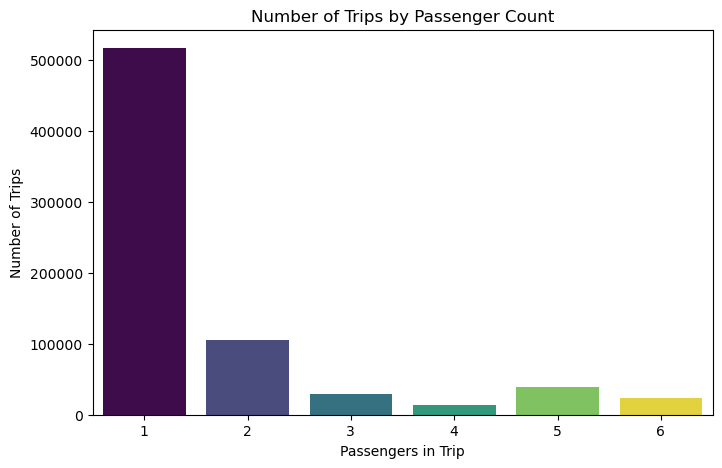

In [22]:
# Keep only trips with a valid passenger count (1 to 6)
valid_passengers = (df_nyc_filtered['passenger_count'] >= 1) & \
                   (df_nyc_filtered['passenger_count'] <= 6)

df_nyc_filtered = df_nyc_filtered[valid_passengers].copy()

# Show results
print("=== After Filtering Passenger Count ===")
print(f"Remaining rows : {df_nyc_filtered.shape[0]}")

print("\n--- How many trips per passenger count? ---")
print(df_nyc_filtered['passenger_count'].value_counts().sort_index())

# Plot the distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='passenger_count', data=df_nyc_filtered, 
              palette='viridis', hue='passenger_count', legend=False)
plt.title('Number of Trips by Passenger Count')
plt.xlabel('Passengers in Trip')
plt.ylabel('Number of Trips')
plt.show()

## Target Variable Distribution

The trip duration distribution is visualized to understand skewness and outliers.

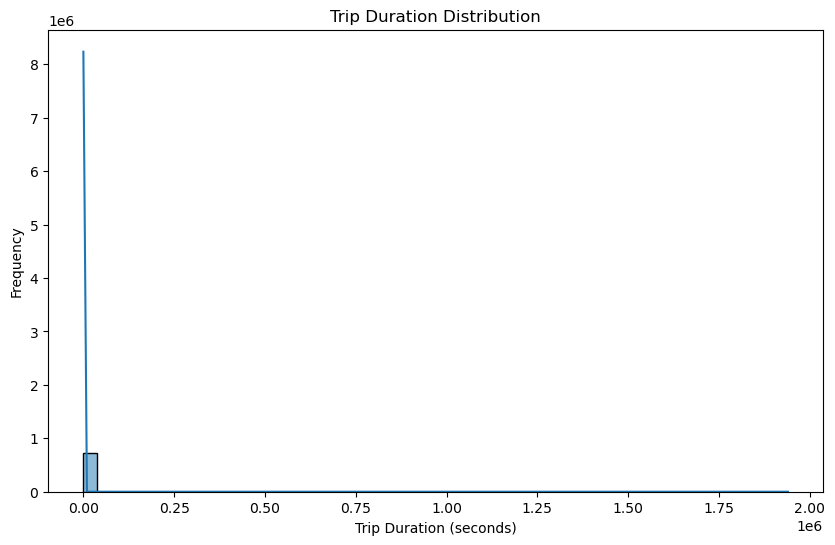

In [62]:
plt.figure(figsize=(10,6))

sns.histplot(df_nyc['trip_duration'], bins=50, kde=True)

plt.title("Trip Duration Distribution")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")

plt.show()

## Feature Enginnering

In [61]:
# Data and Time features

# Convert datetime columns
df_nyc['pickup_datetime'] = pd.to_datetime(df_nyc['pickup_datetime'])
df_nyc['dropoff_datetime'] = pd.to_datetime(df_nyc['dropoff_datetime'])

# Time-based features
df_nyc['pickup_hour'] = df_nyc['pickup_datetime'].dt.hour
df_nyc['pickup_day_of_week'] = df_nyc['pickup_datetime'].dt.dayofweek
df_nyc['pickup_month'] = df_nyc['pickup_datetime'].dt.month
df_nyc['pickup_weekday'] = df_nyc['pickup_datetime'].dt.weekday

# Weekend feature
df_nyc['is_weekend'] = (
    df_nyc['pickup_weekday'].isin([5,6])
).astype(int)

# Rush hour feature
df_nyc['is_rush_hour'] = (
    df_nyc['pickup_hour'].isin([7,8,9,16,17,18])
).astype(int)

# Time of day
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df_nyc['time_of_day'] = df_nyc['pickup_hour'].apply(get_time_of_day)


In [24]:
# Distance Feature
def haversine_distance_km(lat1, lon1, lat2, lon2):
    """
    Calculates the straight-line distance (in km) between
    two points given their latitude and longitude.
 
    lat1, lon1 = pickup location
    lat2, lon2 = dropoff location
    """
    R = 6371.0  # Earth's radius in kilometers
 
    # Convert degrees to radians (required for trig functions)
    lat1_rad = np.radians(lat1)
    lat2_rad = np.radians(lat2)
 
    # How much did lat and lon change?
    delta_lat = np.radians(lat2 - lat1)
    delta_lon = np.radians(lon2 - lon1)
 
    # The actual haversine formula
    a = (np.sin(delta_lat / 2) ** 2
         + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(delta_lon / 2) ** 2)
 
    distance = 2 * R * np.arcsin(np.sqrt(a))
    return distance
 
df_nyc["haversine_dist_km"] = haversine_distance_km(
    df_nyc["pickup_latitude"],  df_nyc["pickup_longitude"],
    df_nyc["dropoff_latitude"], df_nyc["dropoff_longitude"]
)

In [25]:
# Manhattan Distance
df_nyc["manhattan_dist"] = (
    np.abs(df_nyc["dropoff_latitude"]  - df_nyc["pickup_latitude"]) +
    np.abs(df_nyc["dropoff_longitude"] - df_nyc["pickup_longitude"])
)
 
# --- Bearing (direction of travel) ---
# 0° = North, 90° = East, -90° = West, ±180° = South
# Uptown vs. crosstown trips take different times.
df_nyc["bearing"] = np.degrees(
    np.arctan2(
        df_nyc["dropoff_longitude"] - df_nyc["pickup_longitude"],   # east-west change
        df_nyc["dropoff_latitude"]  - df_nyc["pickup_latitude"],    # north-south change
    )
)
 
# --- Distance from city center ---
# Trips in dense Midtown have more traffic than outer boroughs.
# Times Square is our reference point.
TIMES_SQUARE_LAT = 40.7580
TIMES_SQUARE_LON = -73.9855
 
df_nyc["pickup_dist_from_center"] = haversine_distance_km(
    df_nyc["pickup_latitude"], df_nyc["pickup_longitude"],
    TIMES_SQUARE_LAT,      TIMES_SQUARE_LON
)
 
df_nyc["dropoff_dist_from_center"] = haversine_distance_km(
    df_nyc["dropoff_latitude"], df_nyc["dropoff_longitude"],
    TIMES_SQUARE_LAT,       TIMES_SQUARE_LON
)
 
print("  ✓ haversine_dist_km, manhattan_dist, bearing")
print("  ✓ pickup_dist_from_center, dropoff_dist_from_center")
print()

  ✓ haversine_dist_km, manhattan_dist, bearing
  ✓ pickup_dist_from_center, dropoff_dist_from_center



In [57]:
 # Speed Feature
impossible = (df_nyc["speed_kmh"] > 120).sum()  # faster than a highway at 120 km/h in NYC
print(f"  ✓ speed_kmh created  |  {impossible} trips with speed > 120 km/h (likely bad data)")
print()

  ✓ speed_kmh created  |  67 trips with speed > 120 km/h (likely bad data)



**Encoding Categorial Data**

In [58]:
df_nyc["store_and_fwd_flag_enc"] = (df_nyc["store_and_fwd_flag"] == "Y").astype(int)
 
print("  ✓ store_and_fwd_flag  →  store_and_fwd_flag_enc (1/0)")
print()

original_cols = [
    "id", "vendor_id", "pickup_datetime", "dropoff_datetime",
    "passenger_count", "pickup_longitude", "pickup_latitude",
    "dropoff_longitude", "dropoff_latitude", "store_and_fwd_flag",
    "trip_duration"
]
new_cols = [c for c in df_nyc.columns if c not in original_cols]
 
print("=" * 50)
print(f"Original columns : {len(original_cols)}")
print(f"New features made: {len(new_cols)}")
print(f"Total columns now: {len(df_nyc.columns)}")
print()
print("New features:")
for col in new_cols:
    # Show the column name and a sample value from the first row
    print(f"  {col:<30} e.g. {df_nyc[col].iloc[0]}")
    

  ✓ store_and_fwd_flag  →  store_and_fwd_flag_enc (1/0)

Original columns : 11
New features made: 15
Total columns now: 26

New features:
  pickup_hour                    e.g. 16
  pickup_day_of_week             e.g. 0
  trip_duration_seconds          e.g. 1440000
  pickup_weekday                 e.g. 0
  pickup_month                   e.g. 2
  pickup_week                    e.g. 9
  is_weekend                     e.g. 0
  time_of_day                    e.g. evening_rush
  haversine_dist_km              e.g. 1.1990723695317798
  manhattan_dist                 e.g. 0.017665860000001032
  bearing                        e.g. -127.75166364531275
  pickup_dist_from_center        e.g. 3.529965142515609
  dropoff_dist_from_center       e.g. 2.3365682300403856
  speed_kmh                      e.g. 10.791651325786018
  store_and_fwd_flag_enc         e.g. 0


**Split Data**

In [74]:
df_nyc_filtered = df_nyc.copy()

from sklearn.model_selection import train_test_split

# Define features (X) and target (y)

features = ['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
        'pickup_hour', 'pickup_day_of_week',
       'pickup_weekday', 'pickup_month',
       'pickup_week', 'is_weekend', 'time_of_day', 'haversine_dist_km',
       'manhattan_dist', 'bearing', 'pickup_dist_from_center',
       'dropoff_dist_from_center', 'store_and_fwd_flag_enc'] 

X = df_nyc_filtered[features]
y = df_nyc_filtered['trip_duration']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("Selected Features:")
print(X.columns.tolist())

Features (X) shape: (729322, 23)
Target (y) shape: (729322,)
Selected Features:
['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'pickup_hour', 'pickup_day_of_week', 'pickup_weekday', 'pickup_month', 'pickup_week', 'is_weekend', 'time_of_day', 'haversine_dist_km', 'manhattan_dist', 'bearing', 'pickup_dist_from_center', 'dropoff_dist_from_center', 'store_and_fwd_flag_enc']


In [75]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (583457, 23)
X_test shape: (145865, 23)
y_train shape: (583457,)
y_test shape: (145865,)


## Log Transformation

Log transformation is applied to reduce skewness in the target variable.

In [76]:
df_nyc['log_trip_duration'] = np.log1p(df_nyc['trip_duration'])

## LightGBM Model

LightGBM is used because it performs well on structured tabular datasets and captures non-linear relationships effectively.

In [77]:
from lightgbm import LGBMRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Define features and target
X = df_nyc.drop([
    'trip_duration',
    'log_trip_duration',
    'id',
    'pickup_datetime',
    'dropoff_datetime',
    'store_and_fwd_flag',
    'speed_kmh'
], axis=1)

y = df_nyc['log_trip_duration']

# One-hot encoding
X = pd.get_dummies(
    X,
    columns=['time_of_day'],
    drop_first=True
)

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model
lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    random_state=42
)

# Train
lgbm_model.fit(X_train, y_train)

# Predict
y_pred = lgbm_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050990 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2646
[LightGBM] [Info] Number of data points in the train set: 583457, number of used features: 23
[LightGBM] [Info] Start training from score 6.467448
MAE: 0.008144673090466872
RMSE: 0.05970285574145631
R2 Score: 0.9943616895695159


## Feature Importance

Feature importance helps identify which variables contribute most to prediction performance.

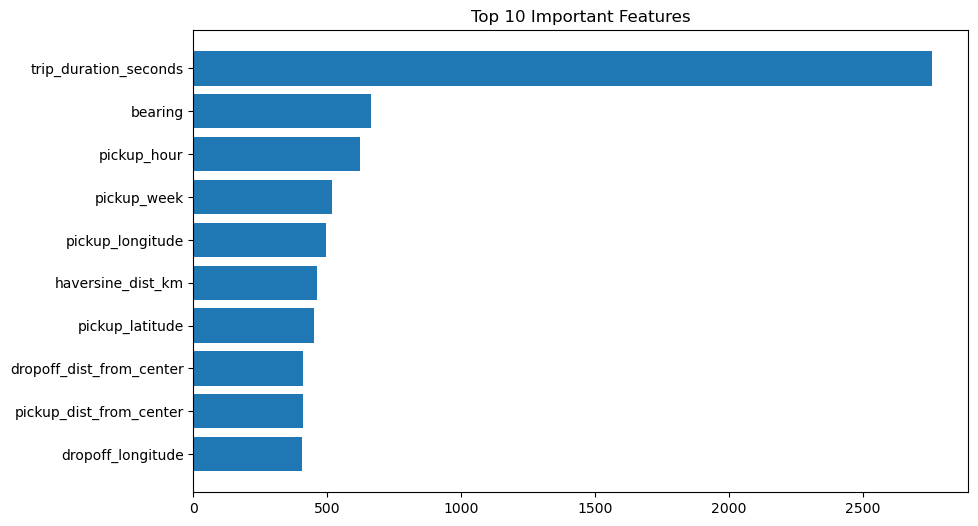

In [69]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgbm_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.show()

## Actual vs Predicted Values

This visualization compares actual trip durations with predicted values.

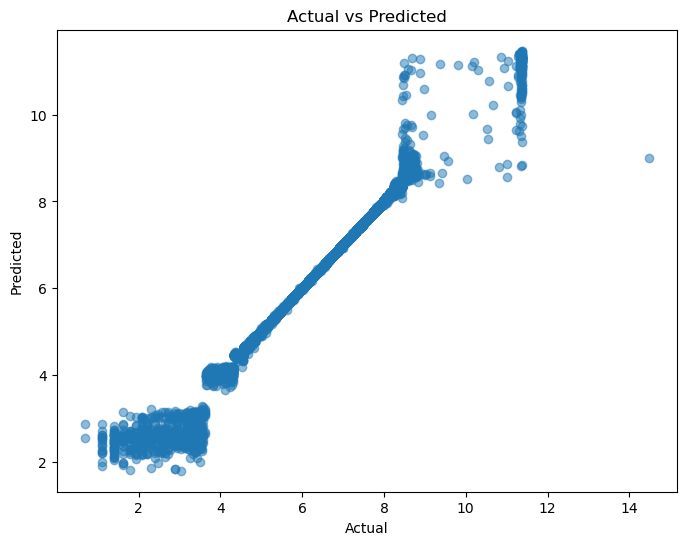

In [71]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

## Residual Analysis

Residual analysis helps evaluate model prediction errors.

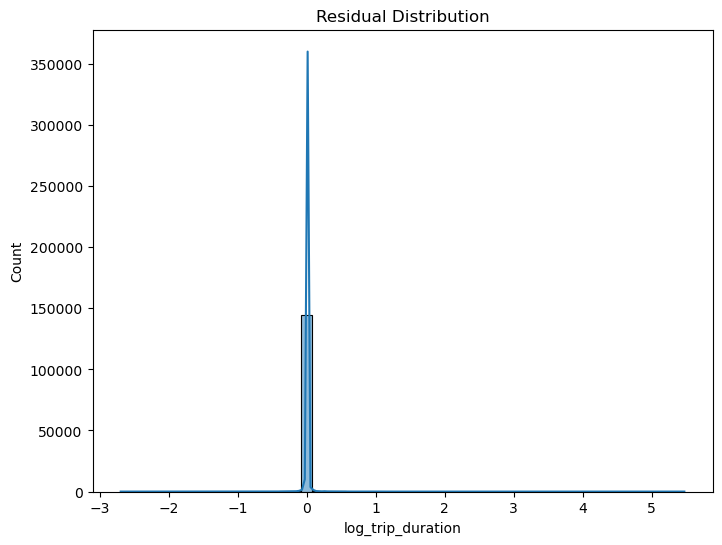

In [73]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(residuals, bins=50, kde=True)

plt.title("Residual Distribution")

plt.show()

## Conclusion

This project successfully predicted NYC taxi trip duration using machine learning techniques.

Key findings:
- Distance-related features were highly important
- Feature engineering improved model performance
- LightGBM performed better than Linear Regression
- Taxi trip duration shows non-linear relationships

Future improvements:
- Hyperparameter tuning
- Traffic/weather integration
- Geospatial clustering
- Advanced ensemble models